# **Libraries**

In [293]:
%run ../../../setup_workspace.py # ../ means level up 

# **Data**

In [294]:
poni_saxs = r"E:\Nps Cu\IHSC 1872\SAXS_1p4m_12keV.poni"
ai_saxs = pyFAI.load(poni_saxs)

poni_waxs = r"E:\Nps Cu\IHSC 1872\WAXS_1p4m_12keV.poni"
ai_waxs = pyFAI.load(poni_waxs)

mask_saxs = r"E:\Nps Cu\IHSC 1872/MASK_SAXS_1p4m_12keV_2.edf"
img_mask_saxs = fabio.open(mask_saxs).data

mask_waxs = r"E:\Nps Cu\IHSC 1872\MASK_WAXS_1p4m_12keV.edf"
img_mask_waxs = fabio.open(mask_waxs).data

In [295]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

# **Functions**

In [296]:
def quick_edit(x, y):
    from ipywidgets import interact, FloatSlider, IntSlider, VBox
    import plotly.graph_objects as go
    from IPython.display import display
    
    y_ed = y.copy()
    
    # Используем CSS для установки размера
    fig = go.FigureWidget()
    fig.add_scatter(x=x, y=y_ed, mode='lines+markers', marker=dict(size=8))
    
    # Устанавливаем размер через layout
    fig.layout.update(
        width=600,
        height=600,
        autosize=False
    )
    
    # Слайдеры
    idx_slider = IntSlider(min=0, max=len(x)-1, step=1, value=0, description='Index:')
    y_slider = FloatSlider(min=float(min(y) / 1.5), max=float(max(y) * 1.5), 
                          value=float(y[0]), step=(max(y)-min(y))/10000,
                          description='Y:', readout_format='.4f')
    
    def update(idx, val):
        y_ed[idx] = val
        fig.data[0].y = y_ed
    
    def on_click(trace, points, selector):
        if points.point_inds:
            idx = points.point_inds[0]
            idx_slider.value = idx
            y_slider.value = y_ed[idx]
    
    fig.data[0].on_click(on_click)
    
    display(fig)
    interact(update, idx=idx_slider, val=y_slider)
    
    return y_ed

def remove_peaks(y, min_width=10):
    peaks = find_peaks(y)[0]
    if len(peaks) == 0:
        return y
    
    widths = peak_widths(y, peaks, rel_height=0.5)[0]
    narrow_peaks = peaks[widths < min_width]
    
    y_clean = y.copy()
    for p in narrow_peaks:
        left = max(0, p - int(widths[peaks == p][0]) * 2)
        right = min(len(y), p + int(widths[peaks == p][0]) * 2)
        y_clean[left:right] = np.linspace(y[left], y[right], right - left)
    
    return y_clean

In [297]:
def Guinier(q, I_0, R_g):
    return I_0 * np.exp(-q ** 2 * R_g ** 2 / 3)

def norm_saxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>4)*(q<5)])
    #return q, I

    

def norm_waxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>20)*(q<20.5)])
    #return q, I

# **Results**

### *Divide*

In [342]:
q, I_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 2000, mask = img_mask_saxs)
Time_heat = Cu_3_heat.get_Time_profile()
q, I_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 2000, mask = img_mask_saxs)
Time_iso = Cu_3_iso.get_Time_profile()

I_3_heat = []
I_3_iso = []

T_3_heat = Cu_3_heat.get_T_profile()[:83]
Time_3_iso = []

for i in range(83):
    I_3_heat.append(I_heat[i])

for i in range(6):
    I_3_iso.append(I_heat[83 + i])
    Time_3_iso.append(Time_heat[83 + i])
time_cur = Time_3_iso[-1]

for i in range(60):
    I_3_iso.append(I_iso[i])
    Time_3_iso.append(Time_iso[i]+time_cur)

Time_3_iso = np.array(Time_3_iso)
T_3_heat = np.array(T_3_heat)


Time_3_iso -= min(Time_3_iso)

print(len(I_3_heat), len(T_3_heat))
print(len(I_3_iso), len(Time_3_iso))

Found 89 EDF files in SAXS
83 83
66 66


In [343]:
q, I_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 2000, mask = img_mask_saxs)
Time_heat = Cu_05_heat.get_Time_profile()
q, I_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 2000, mask = img_mask_saxs)
Time_iso = Cu_05_iso.get_Time_profile()

I_05_heat = []
I_05_iso = []

T_05_heat = Cu_05_heat.get_T_profile()[:83]
Time_05_iso = []

for i in range(83):
    I_05_heat.append(I_heat[i])

for i in range(5):
    I_05_iso.append(I_heat[83 + i])
    Time_05_iso.append(Time_heat[83 + i])

time_cur = Time_05_iso[-1]
for i in range(66):
    I_05_iso.append(I_iso[i])
    Time_05_iso.append(Time_iso[i] + time_cur)

Time_05_iso = np.array(Time_05_iso)
T_05_heat = np.array(T_05_heat)

Time_05_iso -= min(Time_05_iso)

print(len(I_05_heat), len(T_05_heat))
print(len(I_05_iso), len(Time_05_iso))

Found 88 EDF files in SAXS
83 83
71 71


### *Analysis*

##### **Norm**

In [348]:
def norm_saxs(q, I_array):
    for i in range(len(I_array)):
        mask = (q > 6) & (q < 7)  # q в нм⁻¹? 6-7 это очень много
        I_array[i] /= np.mean(I_array[i][mask])
        
def norm_waxs(q, I_data):
    for i in range(len(I_data)):
        I_data[i] /= np.mean(I_data[i][(q>20)*(q<20.5)])

In [345]:
norm_saxs(q, I_3_heat)
norm_saxs(q, I_3_iso)
norm_saxs(q, I_05_heat)
norm_saxs(q, I_05_iso)


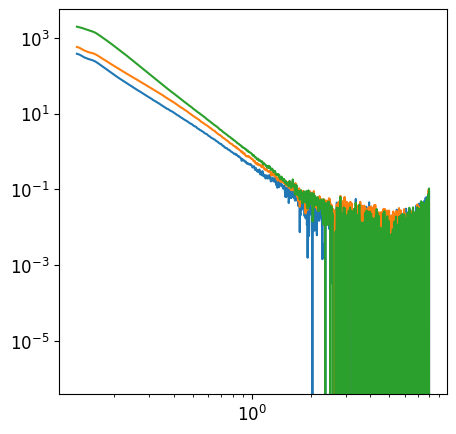

In [347]:
plt.figure(figsize=(5,5))

bkg = I_05_heat[45]
# plt.loglog(q, bkg - 0.995 * bkg)

I = I_05_heat[-1]
plt.loglog(q, I - 0.995 * bkg)

I = I_05_iso[1]
plt.loglog(q, I - 0.995 * bkg)

I = I_05_iso[-1]
plt.loglog(q, I - 0.995 * bkg)

# plt.xlim(0.16, 2)

##### **Guinier**

In [109]:
def linear(x, a, b):
    return a * x + b
    
def Rg_from_fit(a):
    return np.sqrt(3 * np.abs(a))

def fit_fraction(q, I, left, right, plot=True):
    X = q**2
    Y = np.log(I)
    mask = (X > left) & (X < right)
    
    p, _ = curve_fit(linear, X[mask], Y[mask])
    Rg = np.sqrt(-3 * p[0])
    K = np.exp(p[1])
    I_model = K * np.exp(-q**2 * Rg**2 / 3)

    if plot == True:
        plt.figure(figsize=(4,4))
        plt.xlim(0, right)
        plt.ylim(-5, max(Y) * 1.5)
        plt.scatter(X, Y, color='black')
        plt.scatter(X[mask], Y[mask])
        lnsp = np.linspace(0, 4, 1000)
        plt.plot(lnsp, linear(lnsp, *p), color='r', linestyle='--')
        print(Rg)
        
    
    return Rg, K, I_model

In [110]:
Rg_05_heat = []
Rg_05_iso = []

for i in range(len(I_05_heat) - 67):
    I = I_05_heat[67 + i] - 0.995 * bkg

    X = q**2
    Y = np.log(I)

    l = 0.0256
    r = 0.04
    p, cov = curve_fit(linear, X[(X>l)*(X<r)], Y[(X>l)*(X<r)])

    Rg_05_heat.append(np.sqrt(-p[0] * 3))

for i in range(len(I_05_iso)):
    I = I_05_iso[i] - 0.995 * bkg

    X = q**2
    Y = np.log(I)

    l = 0.0256
    r = 0.04
    p, cov = curve_fit(linear, X[(X>l)*(X<r)], Y[(X>l)*(X<r)])

    Rg_05_iso.append(np.sqrt(-p[0] * 3))

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_308\3311690006.py:8: RuntimeWarning:

invalid value encountered in log

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_308\3311690006.py:20: RuntimeWarning:

invalid value encountered in log



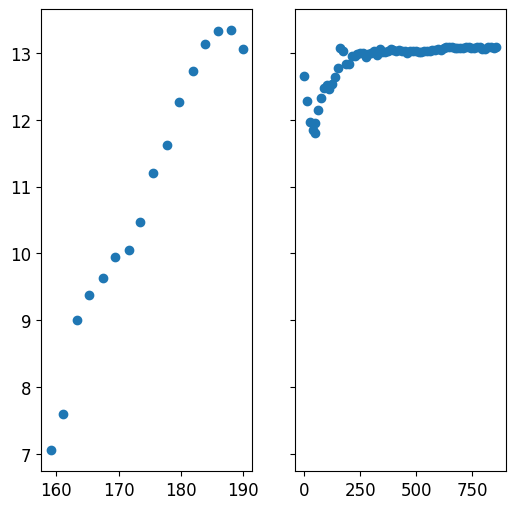

In [111]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 6), sharey=True)

ax1.scatter(T_05_heat[67:], Rg_05_heat)
ax2.scatter(Time_05_iso, Rg_05_iso)

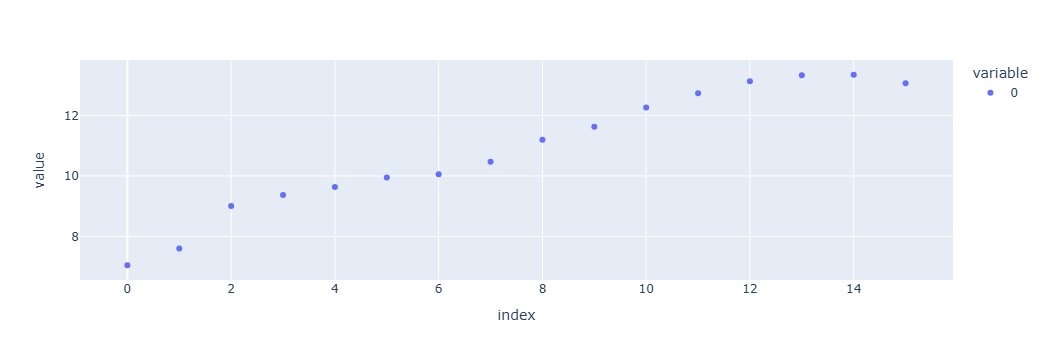

In [96]:
px.scatter(Rg_05_heat)

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_308\578434508.py:4: RuntimeWarning:

invalid value encountered in log



np.float64(7.052603142432187)

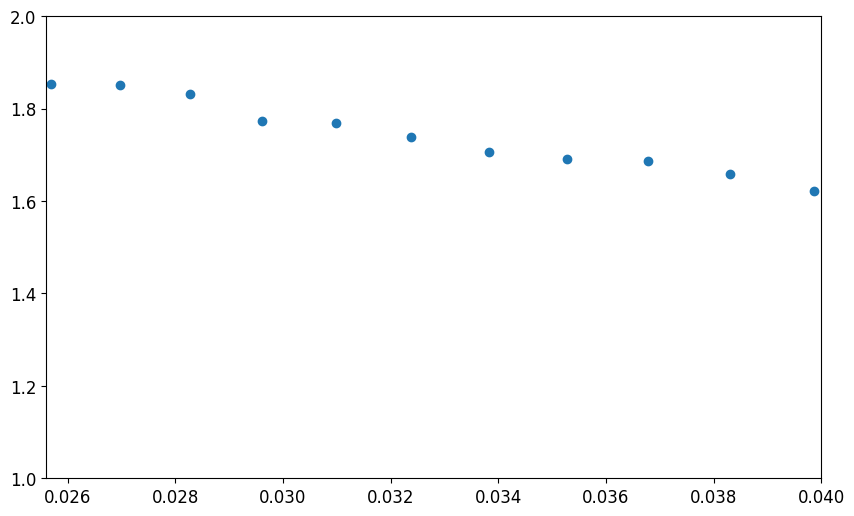

In [92]:
I = I_05_heat[67] - 0.995 * bkg

X = q**2
Y = np.log(I)

plt.scatter(X, Y)
plt.xlim(0.0256, 0.04)

l = 0.0256
r = 0.04
p, cov = curve_fit(linear, X[(X>l)*(X<r)], Y[(X>l)*(X<r)])

plt.ylim(1, 2)

np.sqrt(-p[0] * 3)

###### fractions

1.323160519087866
4.409043100476261


C:\Users\LabPCA\AppData\Local\Temp\ipykernel_308\1910136263.py:9: RuntimeWarning: invalid value encountered in log
  Y = np.log(I)


ValueError: array must not contain infs or NaNs

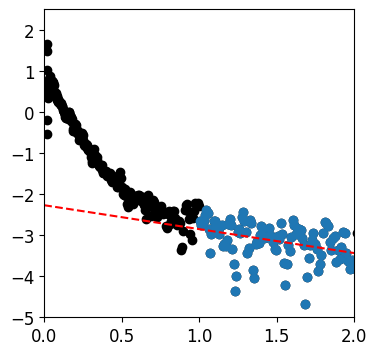

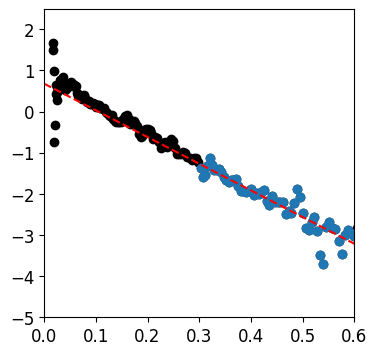

In [65]:
# Использование
I_cur = I_05_heat[65] - 0.995 * bkg

# Фракция 1
R1, K1, I1 = fit_fraction(q, I_cur, left=1., right=2)
I_cur = I_cur - I1  # вычитаем

# Фракция 2
R2, K2, I2 = fit_fraction(q, I_cur, left=0.3, right=0.6)
I_cur = I_cur - I2

# # Фракция 3
R3, K3, I3 = fit_fraction(q, I_cur, left=0.0256, right=0.1)
I_cur = I_cur - I3

# # Фракция 4
# R4, K4, I4 = fit_fraction(q, I_cur, left=0.05, right=0.2)
# I_cur = I_cur - I4

# # Фракция 5
# R5, K5, I5 = fit_fraction(q, I_cur, left=0.025, right=0.05)
# I_cur = I_cur - I5

fractions = [K1, K2, K3]
Rgs = [R1, R2, R3]

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_308\1910136263.py:9: RuntimeWarning:

invalid value encountered in log



1.695324470155041
3.4806515511505243
5.993992884555687
10.315005127052528
17.624462491178143


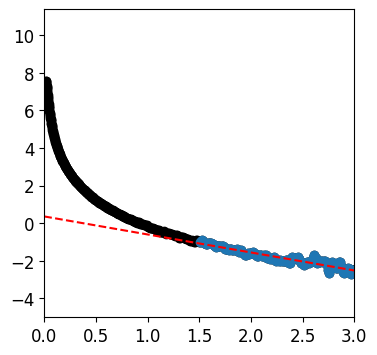

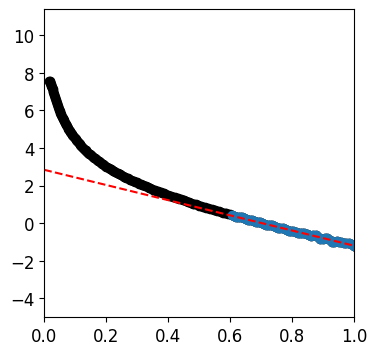

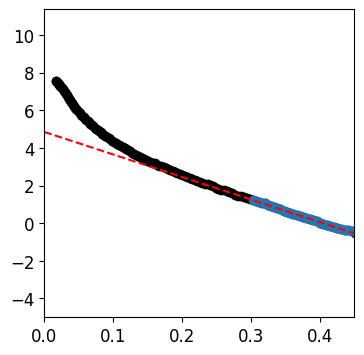

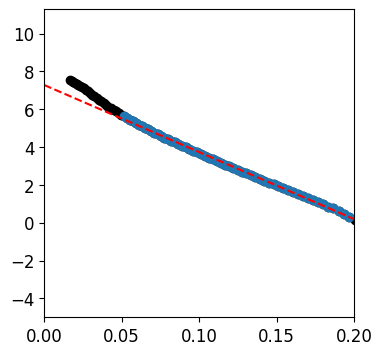

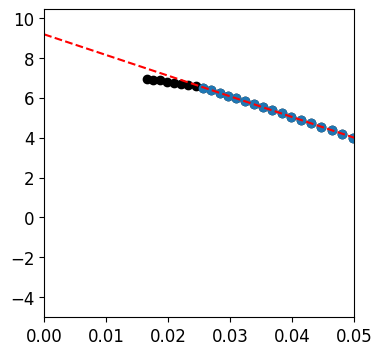

In [507]:
# Использование
bkg = I_05_heat[45]
I_cur = I_05_iso[-1] - 0.995 * bkg

# Фракция 1
R1, K1, I1 = fit_fraction(q, I_cur, left=1.5, right=3)
I_cur = I_cur - I1  # вычитаем

# Фракция 2
R2, K2, I2 = fit_fraction(q, I_cur, left=0.6, right=1.)
I_cur = I_cur - I2

# Фракция 3
R3, K3, I3 = fit_fraction(q, I_cur, left=0.3, right=0.45)
I_cur = I_cur - I3

# Фракция 4
R4, K4, I4 = fit_fraction(q, I_cur, left=0.05, right=0.2)
I_cur = I_cur - I4

# Фракция 5
R5, K5, I5 = fit_fraction(q, I_cur, left=0.025, right=0.05)
I_cur = I_cur - I5

fractions = [K1, K2, K3, K4, K5]
Rgs = [R1, R2, R3, R4, R5]

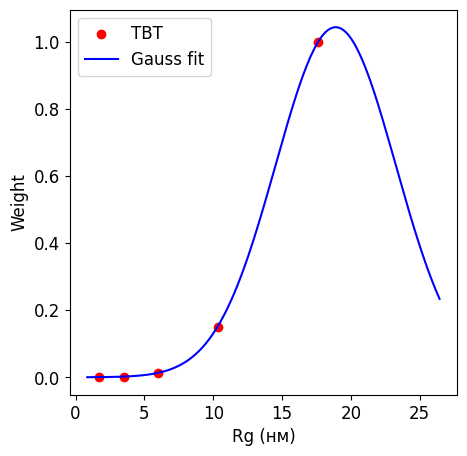

mu = 18.89 нм, sigma = 4.36 нм


In [516]:
from scipy.optimize import curve_fit

def gaussian(R, mu, sigma, A):
    return A * np.exp(-(R - mu)**2 / (2 * sigma**2))

# Фит
popt, _ = curve_fit(gaussian, Rgs, fractions / max(fractions), p0=[Rgs[np.argmax(fractions)], 10, max(fractions)], 
                    maxfev = 5000)

# График
R_cont = np.linspace(min(Rgs)*0.5, max(Rgs)*1.5, 200)

plt.figure(figsize=(5,5))
plt.scatter(Rgs, fractions / max(fractions), color='red', label='TBT')
plt.plot(R_cont, gaussian(R_cont, *popt), 'b-', label='Gauss fit')
plt.xlabel('Rg (нм)')
plt.ylabel('Weight')
plt.legend()
plt.show()

print(f"mu = {popt[0]:.2f} нм, sigma = {popt[1]:.2f} нм")

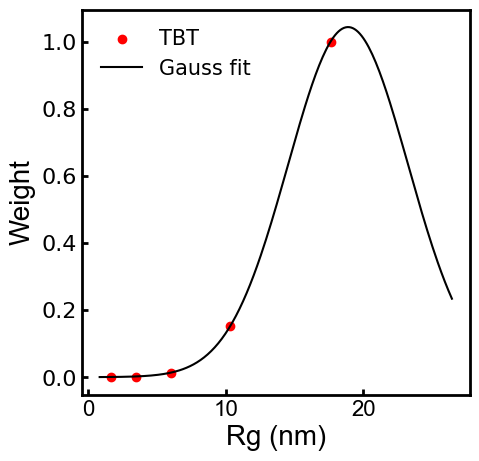

In [520]:
fig, ax = plt.subplots(figsize=(5,5))

# ax.scatter(Time_3_iso, SSA_3_iso_new/max(SSA_3_iso_new), color=color3, label='3%', s=100)
ax.scatter(Rgs, fractions / max(fractions) , color='red', label='TBT')

ax.plot(R_cont, gaussian(R_cont, *popt) , label='Gauss fit', color='black')

ax.set_xlabel(r'Rg (nm)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Weight', fontsize=20, fontfamily='Arial')

ax.legend(fontsize=15, frameon=False)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

for tick in ax.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontfamily('Arial')

    
ax.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)
plt.savefig(r'E:\Nps Cu\Figures v2\Fig5.png', dpi=300, bbox_inches='tight', transparent=True)


##### **invariant**

In [69]:
def power(x, A, p):
    return A * x ** p

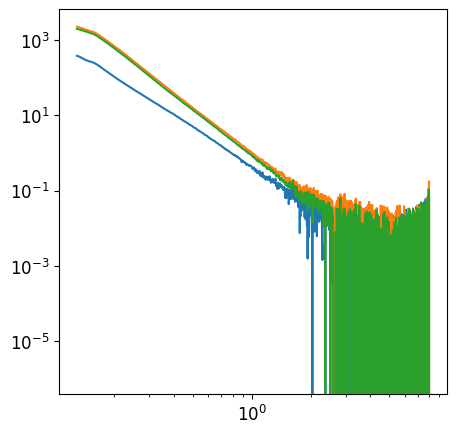

In [124]:
plt.figure(figsize=(5,5))

bkg = I_05_heat[45]
# plt.loglog(q, bkg - 0.995 * bkg)

I = I_05_heat[-1]
plt.loglog(q, I - 0.995 * bkg)
I = I_05_iso[45]
plt.loglog(q, I - 0.995 * bkg)

I = I_05_iso[-1]
plt.loglog(q, I - 0.995 * bkg)

# plt.xlim(0.16, 2)

In [120]:
Q_05_heat = []
Q_05_iso = []

for i in range(len(I_05_heat) - 65):
    I = I_05_heat[65 + i]
    
    X = q[(q<1)*(q>0.2)]
    Y = I[(q<1)*(q>0.2)] * X ** 2

    Q_05_heat.append(np.trapezoid(Y, x=X))

for i in range(len(I_05_iso)):
    I = I_05_iso[i]
    
    X = q[(q<1)*(q>0.2)]
    Y = I[(q<1)*(q>0.2)]* X ** 2
    
    Q_05_iso.append(np.trapezoid(Y, x=X))

In [132]:
Q_3_heat = []
Q_3_iso = []

for i in range(len(I_3_heat) - 65):
    I = I_3_heat[65 + i]
    
    X = q[(q<1)*(q>0.2)]
    Y = I[(q<1)*(q>0.2)] * X ** 2

    Q_3_heat.append(np.trapezoid(Y, x=X))

for i in range(len(I_3_iso)):
    I = I_3_iso[i]
    
    X = q[(q<1)*(q>0.2)]
    Y = I[(q<1)*(q>0.2)]* X ** 2
    
    Q_3_iso.append(np.trapezoid(Y, x=X))

Text(0, 0.5, 'Q (a.u.)')

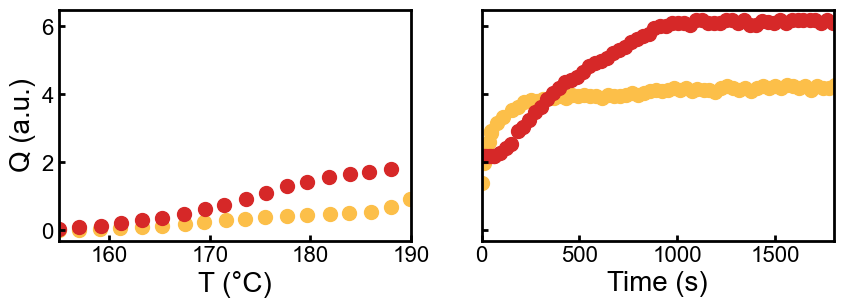

In [185]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

color3 = '#d62828'
color05 = '#fcbf49'

ax1.scatter(T_05_heat[65:], Q_05_heat-Q_05_heat[0], color=color05, s=100)
ax2.scatter(Time_05_iso, Q_05_iso_new-Q_05_heat[0], color=color05, s=100)

ax1.scatter(T_3_heat[65:], Q_3_heat_new-Q_3_heat[0], color=color3, s=100)
ax2.scatter(Time_3_iso, Q_3_iso_new-Q_3_heat[0], color=color3, s=100)

ax2.set_xlim(0, 1801)
ax1.set_xlim(155, 190)

for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)

for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontfamily('Arial')
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontfamily('Arial')

ax1.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)
ax2.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)

ax1.set_xlabel(r'T (°C)', fontsize=20, fontfamily='Arial')
ax2.set_xlabel(r'Time (s)', fontsize=20, fontfamily='Arial')
ax1.set_ylabel(r'Q (a.u.)', fontsize=20, fontfamily='Arial')

In [129]:
Q_05_iso_new = quick_edit(Time_05_iso, Q_05_iso)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '326ce5a8-5c75-418b-9c83-ef6ea6fbcb7b',
              'x': {'bdata': ('AAANABkAJgAyADIAPwBLAFgAZABxAH' ... 'LrAvgCBAMRAx0DKgM2A0IDTwNbAw=='),
                    'dtype': 'i2'},
              'y': [1.9644327261109304, 2.3854802930445476, 2.7977404927121907,
                    3.2710400752392363, 3.6020847341534195, 3.5252912030025265,
                    3.8263812856407506, 3.992721070777675, 4.204905428563427,
                    4.309787228099621, 4.445826797227317, 4.5146884950188015,
                    4.47766258501056, 4.1281138442904775, 3.783490996938319,
                    4.157993334886092, 4.282112368530817, 4.345975827088362,
                    4.300556082501223, 4.245960564099455, 4.365197631703367,
                    4.309557726379272, 4.381119320632539, 3.8357656946287837,
                    4.057319336857285, 3.97200960710

interactive(children=(IntSlider(value=0, description='Index:', max=70), FloatSlider(value=1.9644327261109304, …

In [149]:
Q_3_iso_new = quick_edit(Time_3_iso, Q_3_iso)


FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '9a24322e-7add-4e17-833e-de9313094246',
              'x': {'bdata': ('AAAMABkAJQAxAD4APgBdAHsAmQC4AN' ... 'UTBjEGUAZuBo0GqwbJBugGBgclB0MH'),
                    'dtype': 'i2'},
              'y': [3.271756574554344, 3.26858783613115, 3.083903300721878,
                    2.700812877288067, 2.774770978375265, 2.898955927555134,
                    3.1542876253145113, 3.51575940430137, 3.8726832606406605,
                    4.180712104108519, 4.567887072399172, 4.662435105260224,
                    4.872488793408088, 4.613901492041817, 5.969877720254438,
                    5.197882914855336, 5.805378586413516, 5.9545703051831,
                    5.693463742662269, 5.853385903036061, 5.923321533221917,
                    5.86982038986601, 6.046979314226547, 6.213063958689049,
                    6.322670545174825, 6.415288646405752, 7.0325

interactive(children=(IntSlider(value=0, description='Index:', max=65), FloatSlider(value=3.271756574554344, d…

In [154]:
Q_3_heat_new = quick_edit(T_3_heat[65:], Q_3_heat)


FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '93f74b98-d854-4e12-bb13-75f7a63531fe',
              'x': {'bdata': ('zczMzMwcY0AAAAAAAGBjQAAAAAAAoG' ... 'zMzMz8ZkCamZmZmTlnQAAAAAAAgGdA'),
                    'dtype': 'f8'},
              'y': [1.6445753286462395, 1.680755946180152, 1.723685255497203,
                    1.7722535701902102, 1.8531085799790097, 1.933855733406836,
                    2.012308731465577, 2.130434226120807, 2.261729663575807,
                    2.393347853894398, 2.556439403467816, 2.7358473978459896,
                    2.9520332639738136, 3.055561969592667, 3.199655579851403,
                    3.296291764193316, 3.2073401901328915, 3.1477145530941413]}],
    'layout': {'autosize': False, 'height': 600, 'template': '...', 'width': 600}
})

interactive(children=(IntSlider(value=0, description='Index:', max=17), FloatSlider(value=1.6445753286462395, …

##### **I_111**

In [198]:
q, I_iso = Cu_3_iso.integrate1d_WAXS(ai_waxs, 2000, mask = img_mask_waxs)

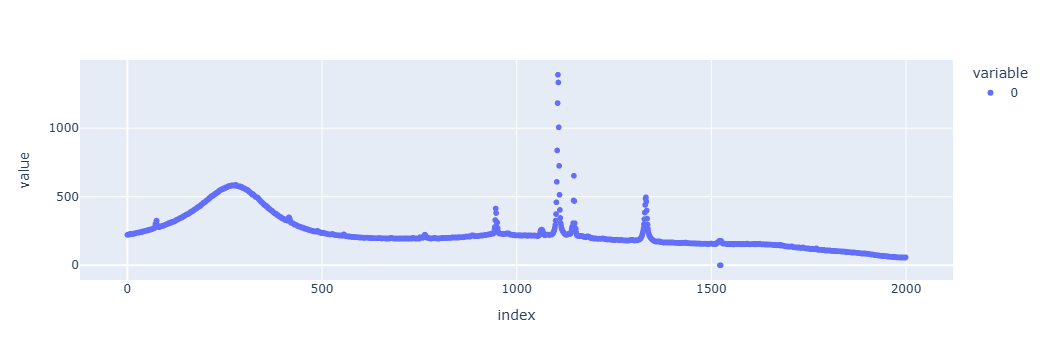

In [199]:
px.scatter(I_iso[-1])

In [220]:
I111_05_heat = []
I111_05_iso = []

q, I_heat = Cu_05_heat.integrate1d_WAXS(ai_waxs, 2000, mask = img_mask_waxs)
norm_waxs(q, I_heat)
for i in range(83):
    I111_05_heat.append(I_heat[i][1105])
for i in range(5):
    I111_05_iso.append(I_heat[83+i][1105])

q, I_iso = Cu_05_iso.integrate1d_WAXS(ai_waxs, 2000, mask = img_mask_waxs)
norm_waxs(q, I_iso)
for i in range(66):
    I111_05_iso.append(I_iso[i][1105])

In [221]:
I111_3_heat = []
I111_3_iso = []

q, I_heat = Cu_3_heat.integrate1d_WAXS(ai_waxs, 2000, mask = img_mask_waxs)
norm_waxs(q, I_heat)
for i in range(83):
    I111_3_heat.append(I_heat[i][1106])
for i in range(6):
    I111_3_iso.append(I_heat[83+i][1106])

q, I_iso = Cu_3_iso.integrate1d_WAXS(ai_waxs, 2000, mask = img_mask_waxs)
norm_waxs(q, I_iso)
for i in range(60):
    I111_3_iso.append(I_iso[i][1106])

In [224]:
I111_3_iso_new = quick_edit(Time_3_iso, I111_3_iso)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '4242bb2a-2ca4-4473-aa38-e98e91c06df9',
              'x': {'bdata': ('AAAMABkAJQAxAD4APgBdAHsAmQC4AN' ... 'UTBjEGUAZuBo0GqwbJBugGBgclB0MH'),
                    'dtype': 'i2'},
              'y': [2.003278970718384, 1.9920802116394043, 1.88968825340271,
                    1.8395140171051025, 1.8733667135238647, 1.8608139753341675,
                    2.0633695125579834, 2.342390298843384, 2.408496379852295,
                    2.5335042476654053, 2.926060199737549, 2.8931846618652344,
                    2.97717547416687, 3.030529260635376, 3.938141107559204,
                    3.706704616546631, 4.0036396980285645, 4.0289387702941895,
                    4.059971809387207, 4.180348873138428, 4.239140510559082,
                    4.125092506408691, 4.31764030456543, 4.501475811004639,
                    4.640167713165283, 4.65704154968261

interactive(children=(IntSlider(value=0, description='Index:', max=65), FloatSlider(value=2.003278970718384, d…

In [222]:
I111_05_iso_new = quick_edit(Time_05_iso, I111_05_iso)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '1b3b5e92-1b62-4982-ab1d-cfa8d674ab80',
              'x': {'bdata': ('AAANABkAJgAyADIAUABvAJ4AvQDbAP' ... 'bvBg0HKwdKB2gHhwelB8QH4gcBCA=='),
                    'dtype': 'i2'},
              'y': [1.3631892204284668, 1.3721662759780884, 1.426740288734436,
                    1.486857533454895, 1.5479744672775269, 1.6557997465133667,
                    1.7757806777954102, 1.8831911087036133, 1.9836269617080688,
                    2.0495622158050537, 2.0489115715026855, 2.050250768661499,
                    1.9384886026382446, 1.9458459615707397, 1.8174548149108887,
                    1.9677945375442505, 1.9142227172851562, 1.9293063879013062,
                    1.959783673286438, 1.978621006011963, 1.9869189262390137,
                    1.986375331878662, 2.027952194213867, 1.8774821758270264,
                    1.9835717678070068, 1.95

interactive(children=(IntSlider(value=0, description='Index:', max=70), FloatSlider(value=1.3631892204284668, …

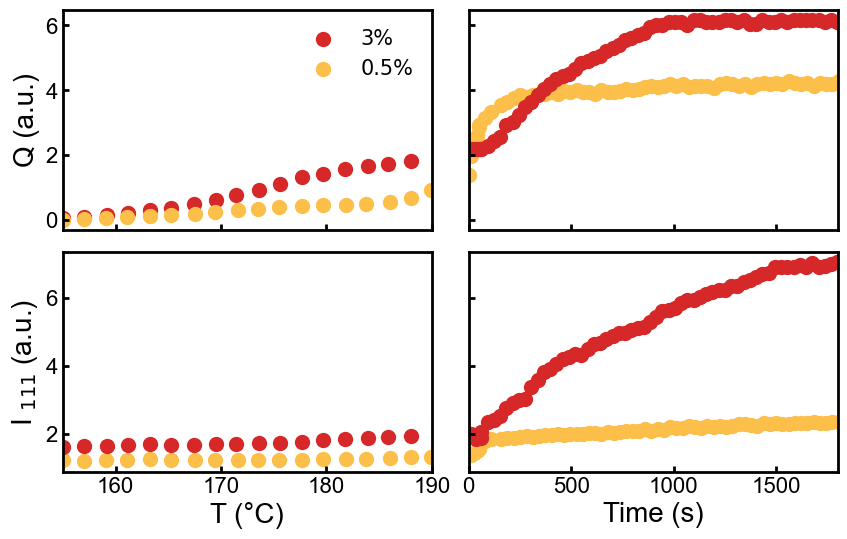

In [233]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6), 
                        sharex='col',  # общие оси X в столбцах
                        sharey='row',  # общие оси Y в строках
                        gridspec_kw={'hspace': 0.1, 'wspace': 0.1})

# Извлекаем оси для удобства
(ax1, ax2), (ax3, ax4) = axs

color3 = '#d62828'
color05 = '#fcbf49'
ax1.scatter(T_3_heat[65:], Q_3_heat_new-Q_3_heat[0], color=color3, s=100, label='3%')
ax1.scatter(T_05_heat[65:], Q_05_heat-Q_05_heat[0], color=color05, s=100, label='0.5%')
ax2.scatter(Time_05_iso, Q_05_iso_new-Q_05_heat[0], color=color05, s=100)
ax2.scatter(Time_3_iso, Q_3_iso_new-Q_3_heat[0], color=color3, s=100)

ax3.scatter(T_05_heat, I111_05_heat, color=color05, s=100)
ax4.scatter(Time_05_iso, I111_05_iso_new, color=color05, s=100)

ax3.scatter(T_3_heat, I111_3_heat, color=color3, s=100)
ax4.scatter(Time_3_iso, I111_3_iso_new, color=color3, s=100)

ax4.set_xlim(0, 1801)
ax3.set_xlim(155, 190)

for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax3.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax4.spines[axis].set_linewidth(2)

for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontfamily('Arial')
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontfamily('Arial')
for tick in ax3.get_xticklabels() + ax3.get_yticklabels():
    tick.set_fontfamily('Arial')
for tick in ax4.get_xticklabels() + ax4.get_yticklabels():
    tick.set_fontfamily('Arial')
    
ax1.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)
ax2.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)
ax3.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)
ax4.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)

ax3.set_xlabel(r'T (°C)', fontsize=20, fontfamily='Arial')
ax4.set_xlabel(r'Time (s)', fontsize=20, fontfamily='Arial')
ax1.set_ylabel(r'Q (a.u.)', fontsize=20, fontfamily='Arial')
ax3.set_ylabel(r'I $_{111}$ (a.u.)', fontsize=20, fontfamily='Arial')
ax1.legend(fontsize=15, frameon=False)

plt.savefig(r'E:\Nps Cu\Figures v2\Fig3.png', dpi=300, bbox_inches='tight', transparent=True)


In [236]:
import pandas as pd

# Создаем DataFrame со всеми использованными данными
data = {
    'T_3_heat': T_3_heat[65:],
    'Q_3_heat': Q_3_heat_new - Q_3_heat[0],
    'T_05_heat': T_05_heat[65:],
    'Q_05_heat': Q_05_heat - Q_05_heat[0],
    'Time_05_iso': Time_05_iso,
    'Q_05_iso': Q_05_iso_new - Q_05_heat[0],
    'Time_3_iso': Time_3_iso,
    'Q_3_iso': Q_3_iso_new - Q_3_heat[0],
    'T_05_heat_I': T_05_heat,
    'I111_05_heat': I111_05_heat,
    'Time_05_iso_I': Time_05_iso,
    'I111_05_iso': I111_05_iso_new,
    'T_3_heat_I': T_3_heat,
    'I111_3_heat': I111_3_heat,
    'Time_3_iso_I': Time_3_iso,
    'I111_3_iso': I111_3_iso_new
}

df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data.items()]))
df.to_csv(r'E:\Nps Cu\Figures v2\Fig3_data.txt', index=False, sep=str('\t'))
df.head()

,T_3_heat,Q_3_heat,T_05_heat,Q_05_heat,Time_05_iso,Q_05_iso,Time_3_iso,Q_3_iso,T_05_heat_I,I111_05_heat,Time_05_iso_I,I111_05_iso,T_3_heat_I,I111_3_heat,Time_3_iso_I,I111_3_iso
0,152.9,0.000013,155.0,0.000000,0.0,1.381749,0.0,2.183113,20.6,1.568240,0.0,1.363223,20.0,1.530778,0.0,2.003447
1,155.0,0.036181,157.0,0.016690,13.0,1.960613,12.0,2.183113,23.1,1.555785,13.0,1.372166,20.6,1.538517,12.0,1.992080
2,157.0,0.079110,159.1,0.039967,25.0,2.394906,25.0,2.183113,25.2,1.565670,25.0,1.426740,22.9,1.526852,25.0,1.889688
3,159.2,0.127678,161.1,0.067193,38.0,2.593078,37.0,2.183113,27.2,1.545131,38.0,1.486858,25.2,1.521560,37.0,1.839514
4,161.2,0.208533,163.3,0.099331,50.0,2.924123,49.0,2.183113,29.4,1.534810,50.0,1.547974,27.2,1.515498,49.0,1.873367


##### **SSA**

In [362]:
def porod(q, C_p):
    return C_p * q**(-4)

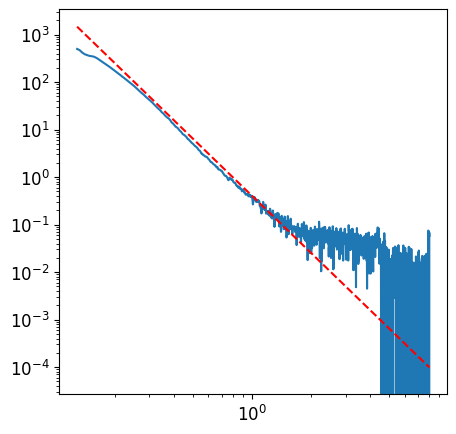

C_p = 4.04e-01


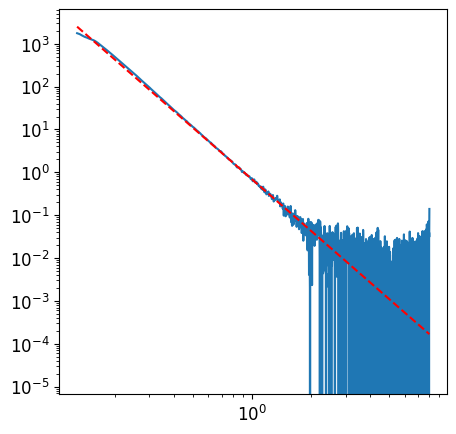

C_p = 6.86e-01


In [481]:
plt.figure(figsize=(5,5))

bkg = I_3_heat[45]
I = I_3_iso[5]
Y = I - 1 * bkg

plt.loglog(q, Y)

mask = (q > 1.) & (q < 2)
p, _ = curve_fit(porod, q[mask], Y[mask])

plt.plot(q, porod(q, *p), 'r--')
plt.show()

print(f"C_p = {p[0]:.2e}")

plt.figure(figsize=(5,5))
I = I_3_iso[10]
Y = I - .995 * bkg

plt.loglog(q, Y)

mask = (q > 1.) & (q < 2)
p, _ = curve_fit(porod, q[mask], Y[mask])

plt.plot(q, porod(q, *p), 'r--')
plt.show()

print(f"C_p = {p[0]:.2e}")

In [482]:
bkg = I_05_heat[45]
porods_05_iso = []

for i in range(len(Time_05_iso)):
    I = I_05_iso[i]
    Y = I - 0.995 * bkg
    mask = (q > 1) & (q < 2)
    p, _ = curve_fit(porod, q[mask], Y[mask])

    porods_05_iso.append(p[0])

bkg = I_3_heat[45]
porods_3_iso = []

for i in range(len(Time_3_iso)):
    I = I_3_iso[i]
    Y = I - 1 * bkg
    mask = (q > 1.5) & (q < 2)
    p, _ = curve_fit(porod, q[mask], Y[mask])

    porods_3_iso.append(p[0])

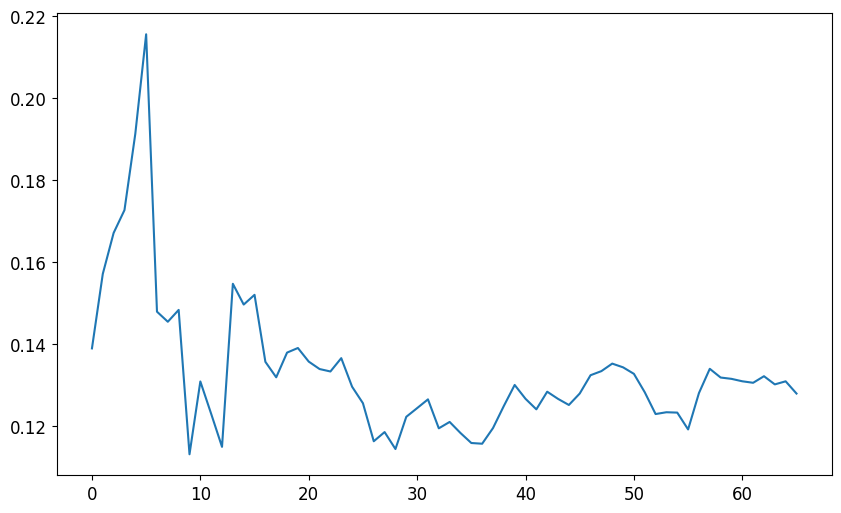

In [483]:
# plt.plot(porods_05_iso)
plt.plot(porods_3_iso / Q_3_iso)

In [484]:
Q_3_iso = np.array(Q_3_iso)
Q_05_iso = np.array(Q_05_iso)
porods_3_iso = np.array(porods_3_iso)
porods_05_iso = np.array(porods_05_iso)

SSA_3_iso = porods_3_iso / Q_3_iso
SSA_05_iso = porods_05_iso / Q_05_iso

In [485]:
SSA_3_iso_new = quick_edit(Time_3_iso, SSA_3_iso)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '5a9d49d2-3b6f-4ae9-b790-2ef915784aeb',
              'x': {'bdata': ('AAAMABkAJQAxAD4APgBdAHsAmQC4AN' ... 'UTBjEGUAZuBo0GqwbJBugGBgclB0MH'),
                    'dtype': 'i2'},
              'y': {'bdata': ('uTrL82rJwT9di4HLxBzEP7y0aHISZM' ... 'idmuipwD/KV1Ilh8LAPxAJFW2/YMA/'),
                    'dtype': 'f8'}}],
    'layout': {'autosize': False, 'height': 600, 'template': '...', 'width': 600}
})

interactive(children=(IntSlider(value=0, description='Index:', max=65), FloatSlider(value=0.1389592829131823, …

In [466]:
SSA_05_iso_new = quick_edit(Time_05_iso, SSA_05_iso)


FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '91164b6b-4af5-4d66-b157-6c737295ec98',
              'x': {'bdata': ('AAANABkAJgAyADIAUABvAJ4AvQDbAP' ... 'bvBg0HKwdKB2gHhwelB8QH4gcBCA=='),
                    'dtype': 'i2'},
              'y': {'bdata': ('y1BFyzgo0T+MjCZTJ1PRP7CpeBZW0N' ... '10+Mk/LmXOV1URyj9C22WSR9DJPw=='),
                    'dtype': 'f8'}}],
    'layout': {'autosize': False, 'height': 600, 'template': '...', 'width': 600}
})

interactive(children=(IntSlider(value=0, description='Index:', max=70), FloatSlider(value=0.268079947001081, d…

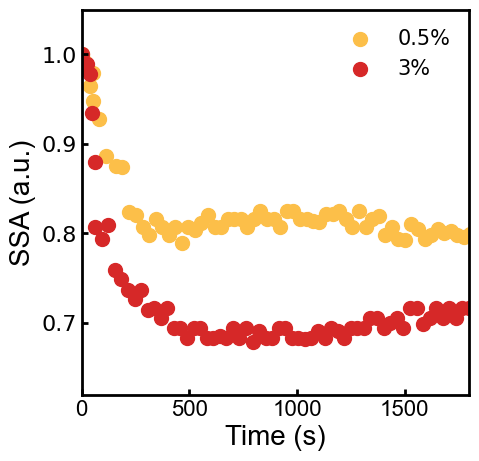

In [499]:
fig, ax = plt.subplots(figsize=(5,5))

# ax.scatter(Time_3_iso, SSA_3_iso_new/max(SSA_3_iso_new), color=color3, label='3%', s=100)
ax.scatter(Time_05_iso, SSA_05_iso_new/max(SSA_05_iso_new), color=color05, label='0.5%', s=100)

ax.scatter(Time_3_iso, SSA_3_iso_new/max(SSA_3_iso_new), color=color3, label='3%', s=100)

ax.set_xlabel(r'Time (s)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'SSA (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0, 1800)
ax.set_ylim(0.62, 1.05)

ax.legend(fontsize=15, frameon=False)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

for tick in ax.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontfamily('Arial')

    
ax.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)
plt.savefig(r'E:\Nps Cu\Figures v2\Fig4.png', dpi=300, bbox_inches='tight', transparent=True)


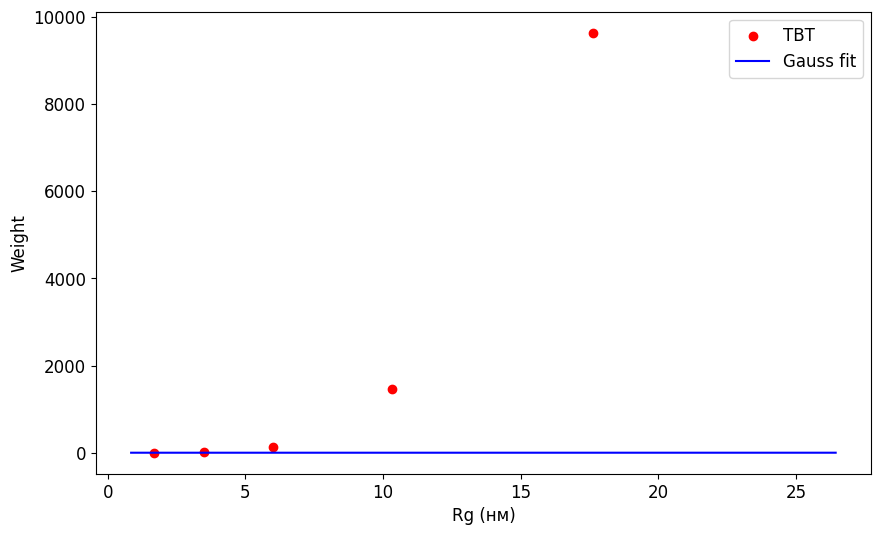

mu = 18.89 нм, sigma = 4.36 нм


In [521]:
plt.figure()
plt.scatter(Rgs, fractions, color='red', label='TBT')
plt.plot(R_cont, gaussian(R_cont, *popt), 'b-', label='Gauss fit')
plt.xlabel('Rg (нм)')
plt.ylabel('Weight')
plt.legend()
plt.show()

print(f"mu = {popt[0]:.2f} нм, sigma = {popt[1]:.2f} нм")

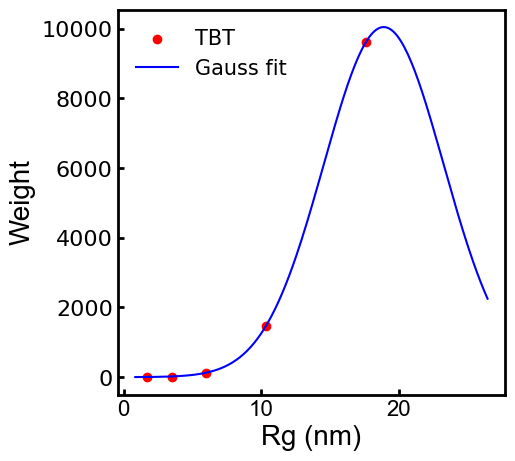

In [512]:
fig, ax = plt.subplots(figsize=(5,5))

# ax.scatter(Time_3_iso, SSA_3_iso_new/max(SSA_3_iso_new), color=color3, label='3%', s=100)
ax.scatter(Rgs, fractions , color='red', label='TBT')

ax.plot(R_cont, gaussian(R_cont, *popt) , 'b-', label='Gauss fit')

ax.set_xlabel(r'Rg (nm)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Weight', fontsize=20, fontfamily='Arial')

ax.legend(fontsize=15, frameon=False)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

for tick in ax.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontfamily('Arial')

    
ax.tick_params(axis="both", which='both', direction="in", width=2, length=4, labelsize=16)
plt.savefig(r'E:\Nps Cu\Figures v2\Fig5.png', dpi=300, bbox_inches='tight', transparent=True)
